# Tensor

In [2]:
import torch 
import numpy as np

In [12]:
data = [[1,2], [3,4]]
x_data = torch.tensor(data)


In [13]:
np_array = np.array(data)
x_np = torch.from_numpy(np_array)

In [17]:
n = np.ones(5)
t = torch.from_numpy(n)

t

tensor([1., 1., 1., 1., 1.], dtype=torch.float64)

In [18]:
np.add(n, 1, out=n)
print(n)
print(t)

[2. 2. 2. 2. 2.]
tensor([2., 2., 2., 2., 2.], dtype=torch.float64)


In [ ]:
# mini exercise

x = torch.randn(32, 200)
x.mean(dim=1, keepdim=True)

torch.Size([32, 1])

In [29]:
rez = (x - x.mean(dim=1, keepdim=True)) / x.std(dim=1, keepdim=True)

In [32]:
rez.mean(dim=1)

tensor([-1.0729e-08,  7.1526e-09,  5.9605e-09,  2.3842e-09,  1.1921e-09,
         4.7684e-09,  1.9073e-08, -2.6226e-08,  1.1921e-08,  2.2650e-08,
         2.3842e-09, -1.4305e-08,  9.5367e-09,  2.6226e-08,  4.7684e-09,
        -2.3842e-09, -2.0862e-08,  9.5367e-09, -7.1526e-09,  0.0000e+00,
         0.0000e+00, -1.1921e-09,  9.5367e-09,  5.3644e-09,  4.7684e-09,
        -1.0133e-08,  8.3447e-09,  0.0000e+00,  4.7684e-09,  7.1526e-09,
        -9.5367e-09,  1.1921e-09])

In [33]:
rez.std(dim=1)

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000])

In [34]:
if torch.accelerator.is_available():
    rez = rez.to(torch.accelerator.current_accelerator())



In [35]:
rez[0]

tensor([ 0.0313, -0.5892,  0.5392, -1.9325,  2.0597,  0.4654, -0.1604, -1.3123,
        -1.6005, -1.5021, -0.1282, -0.6023,  0.1006, -2.0294,  1.9401, -1.6247,
         0.5629, -0.2168,  1.0395,  1.8556,  0.6795, -0.5998,  0.1167,  0.6543,
         0.5056,  1.0921, -1.6029, -0.2222, -0.5183, -0.9309,  0.1055,  1.2817,
        -0.3371,  0.6342, -0.2874, -0.8130, -1.1505,  2.6751,  1.6541, -0.1889,
         0.7987,  0.4590, -0.7436, -0.2674, -2.8114,  0.6575,  1.4144, -0.1545,
        -0.1659, -0.6400,  1.2839, -0.7099, -1.0063, -1.0377,  1.1494, -0.5457,
         1.0607,  0.1872,  1.4192,  0.5314, -0.8451, -0.8355,  0.0683, -0.6143,
        -1.5915,  0.9260,  0.7530,  0.7188,  1.4505,  0.1277,  0.4247, -0.8002,
        -1.6572,  0.8886,  0.2205,  0.2946,  0.0725,  0.2093, -0.0185,  0.0722,
        -0.3092, -1.5901,  1.3880, -0.9141, -0.0203, -0.7261, -0.1721, -1.2253,
        -1.0138, -1.2506,  0.1987,  1.5731, -0.3592,  0.3509, -0.5136,  1.4675,
         0.4657, -0.4771, -0.7445,  0.96

In [36]:
rez[:,0]


tensor([ 0.0313,  0.1506, -1.8942,  0.8462, -0.7120,  1.7821,  0.9592,  1.9180,
         1.6010,  0.2443, -1.3346, -0.3241, -0.3829, -0.0940, -0.0493, -1.7321,
        -0.2040, -0.8769, -1.5860,  0.4917, -1.3643,  1.1643,  0.4635, -0.9839,
        -0.0755,  0.0157, -0.7151,  1.1809, -0.0175,  1.1497, -1.1288, -0.9510],
       device='mps:0')

In [39]:
(rez @ rez.T).shape

torch.Size([32, 32])

# Datasets & DataLoader

In [44]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import v2
import matplotlib.pyplot as plt

training_data = datasets.FashionMNIST(
    root='data',
    train=True,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

test_data = datasets.FashionMNIST(
    root='data',
    train=False,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

100.0%
100.0%
100.0%
100.0%


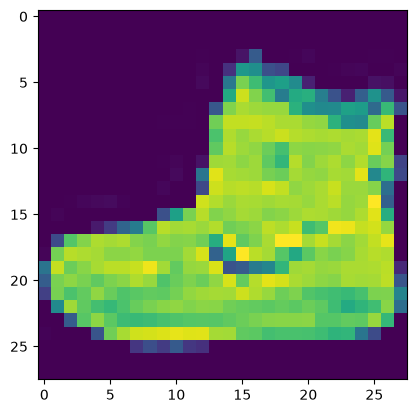

In [52]:
plt.imshow(training_data[0][0].squeeze())

In [54]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True)

print(f"Dataloader size: {len(train_dataloader)}")


    

Dataloader size: 938


In [57]:
next(iter(train_dataloader))

[tensor([[[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           ...,
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]],
 
 
         [[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           ...,
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]],
 
 
         [[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000

In [76]:
# mini exercise
class customDataset(Dataset):
    def __init__(self, n_series=8, n_features=100):
        self.n_series = n_series
        self.n_features = n_features

    def __len__(self):
        return self.n_series

    def __getitem__(self, idx):
        g = torch.Generator()
        g.manual_seed(idx)
        return torch.randn(100, generator=g), idx % 2

train_dataloader = DataLoader(customDataset(), batch_size=8, shuffle=True)
test_dataloader = DataLoader(customDataset(), batch_size=8, shuffle=True)

print(f"Dataloader size: {len(train_dataloader)}")
print(train_dataloader.batch_size)
x, y = next(iter(train_dataloader))
print(x.shape)
print(y.shape)




Dataloader size: 1
8
torch.Size([8, 100])
torch.Size([8])


# Build Model & Autograd

In [77]:
import os
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [78]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f'Using {device} device')

Using mps device


In [82]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits


In [83]:
model = NeuralNetwork().to(device)
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [84]:
X = torch.rand(1, 28, 28, device=device)
logits = model(X)
pred_probab = nn.Softmax(dim=1)(logits)
y_pred = pred_probab.argmax(dim=1)
print(f"predicted class: {y_pred}")

predicted class: tensor([4], device='mps:0')


In [85]:
input_image = torch.rand(3, 28, 28)
print(input_image.size())

torch.Size([3, 28, 28])


In [86]:
flatten = nn.Flatten()
flat_image = flatten(input_image)
print(flat_image.size())

torch.Size([3, 784])


In [87]:
layer1 = nn.Linear(in_features=28*28, out_features=20)
hidden1 = layer1(flat_image)
print(hidden1.size())

torch.Size([3, 20])


In [88]:
print(f"Before RuLU: {hidden1} \n\n")
hidden1 = nn.ReLU()(hidden1)
print(f"After ReLU: {hidden1}")

Before RuLU: tensor([[ 0.0799, -0.2603, -0.1393,  0.0456,  0.1229, -0.0506, -0.4148,  0.3173,
         -0.8371, -0.1891, -0.0758, -0.0781,  0.2425, -0.3686, -0.1977, -0.4126,
          0.0720, -0.2647, -0.0616,  0.3665],
        [ 0.2112, -0.2940,  0.0391,  0.2664,  0.1111, -0.0897,  0.0115,  0.4859,
         -0.5242, -0.1935,  0.2472, -0.1614, -0.0438, -0.4145, -0.2408, -0.2128,
          0.1090, -0.0717, -0.1020,  0.2265],
        [ 0.4117, -0.3969,  0.0201, -0.0768, -0.0631, -0.0340, -0.2228,  0.4253,
         -0.5856, -0.1245,  0.1081, -0.0540,  0.2404, -0.3523, -0.1651,  0.1411,
         -0.2084, -0.0208, -0.1354,  0.3424]], grad_fn=<AddmmBackward0>) 


After ReLU: tensor([[0.0799, 0.0000, 0.0000, 0.0456, 0.1229, 0.0000, 0.0000, 0.3173, 0.0000,
         0.0000, 0.0000, 0.0000, 0.2425, 0.0000, 0.0000, 0.0000, 0.0720, 0.0000,
         0.0000, 0.3665],
        [0.2112, 0.0000, 0.0391, 0.2664, 0.1111, 0.0000, 0.0115, 0.4859, 0.0000,
         0.0000, 0.2472, 0.0000, 0.0000, 0.0000, 0.0

In [89]:
seq_modules = nn.Sequential(
    flatten,
    layer1,
    nn.ReLU(),
    nn.Linear(20, 10)
)
input_image = torch.rand(3, 28, 28)
logits = seq_modules(input_image)


In [90]:
softmax = nn.Softmax(dim=1)
pred_probab = softmax(logits)
pred_probab

tensor([[0.1139, 0.1148, 0.0782, 0.0863, 0.1091, 0.0876, 0.1160, 0.1047, 0.0993,
         0.0901],
        [0.1253, 0.1138, 0.0904, 0.0852, 0.1050, 0.0869, 0.1181, 0.0964, 0.0966,
         0.0822],
        [0.1235, 0.1158, 0.0766, 0.0867, 0.1071, 0.0818, 0.1193, 0.1027, 0.1036,
         0.0829]], grad_fn=<SoftmaxBackward0>)

In [91]:
print(f"Model structure: {model}\n\n")

for name, param in model.named_parameters():
    print(f"Layer: {name} | Size: {param.size()} | Values : {param[:2]} \n")

Model structure: NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


Layer: linear_relu_stack.0.weight | Size: torch.Size([512, 784]) | Values : tensor([[-0.0036, -0.0223,  0.0147,  ...,  0.0206, -0.0163, -0.0162],
        [ 0.0125,  0.0061,  0.0069,  ..., -0.0153, -0.0249, -0.0347]],
       device='mps:0', grad_fn=<SliceBackward0>) 

Layer: linear_relu_stack.0.bias | Size: torch.Size([512]) | Values : tensor([0.0171, 0.0251], device='mps:0', grad_fn=<SliceBackward0>) 

Layer: linear_relu_stack.2.weight | Size: torch.Size([512, 512]) | Values : tensor([[-0.0133, -0.0032, -0.0109,  ..., -0.0201,  0.0161, -0.0258],
        [-0.0021, -0.0053, -0.0440,  ...,  0.0018, -0.0226,  0.0227]],
       device='mps:0', grad_fn=<SliceBa

In [92]:
import torch

x = torch.ones(5)
y = torch.zeros(3)
w = torch.randn(5, 3, requires_grad=True)
b = torch.randn(3, requires_grad=True)
z = torch.matmul(x, w) + b
loss = torch.nn.functional.binary_cross_entropy_with_logits(z, y)


In [93]:
print(f"Gradient function for z = {z.grad_fn}")
print(f"Gradient function for loss = {loss.grad_fn}")

Gradient function for z = <AddBackward0 object at 0x11bab82b0>
Gradient function for loss = <BinaryCrossEntropyWithLogitsBackward0 object at 0x11bab8280>


In [94]:
loss.backward()
print(w.grad)
print(b.grad)


tensor([[0.2879, 0.0211, 0.1502],
        [0.2879, 0.0211, 0.1502],
        [0.2879, 0.0211, 0.1502],
        [0.2879, 0.0211, 0.1502],
        [0.2879, 0.0211, 0.1502]])
tensor([0.2879, 0.0211, 0.1502])


In [95]:
z = torch.matmul(x, w) + b
print(z.requires_grad)

with torch.no_grad():
    z = torch.matmul(x, w) + b
print(z.requires_grad)

True
False


In [96]:
z = torch.matmul(x, w) + b
z_det = z.detach()
print(z_det.requires_grad)

False


In [102]:
# mini exercise
x = torch.randn(10, 5)
w = torch.randn(5, 1, requires_grad=True)
b = torch.randn(1, requires_grad=True)
z = torch.matmul(x, w) + b
y = torch.randn(10, 1)
loss = ((z - y) ** 2).mean()
loss.backward()
print(w.grad, b.grad)
print( 2 / 10 * torch.matmul(x.T, (z - y)))

tensor([[ 4.8791],
        [ 1.1823],
        [-2.5330],
        [-3.0318],
        [ 4.3292]]) tensor([1.1671])
tensor([[ 4.8791],
        [ 1.1823],
        [-2.5330],
        [-3.0318],
        [ 4.3292]], grad_fn=<MulBackward0>)


# understanding check
(1) - because __call__ will call other hooks; calling forward directly misses those (such as gradient tracking)
(2) - gradients are always added on top; if not zeroed, it will be off by the gradients from last step
(3) - it stops gradient tracking; this freezes gradients and speeds up computation

# Optimization + Save & Load

In [103]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets 
from torchvision.transforms import v2 

training_data = datasets.FashionMNIST(
    root='data',
    train=True,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

test_data = datasets.FashionMNIST(
    root='data',
    train=False,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

train_dataloader = DataLoader(training_data, batch_size=64)
test_dataloader = DataLoader(test_data, batch_size=64)

class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = NeuralNetwork()


In [104]:
learning_rate = 1e-3
batch_size = 64
epochs = 5


In [105]:
loss_fn = nn.CrossEntropyLoss()

In [106]:
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [108]:
def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    # set the model to training mode - important for batch normalization and dropout layers
    # unnecessary in this situation but added for best practices
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        # compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, y)

        # backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), batch * batch_size + len(X)
            print(f"loss: {loss:>7f} [{current:>5d} / {size:>5d}]")

def test_loop(dataloader, model, loss_fn):
    # set the model to evaluation mode - important for batch normalization and dropout layers
    # unnecessary in this situation but added for best practices
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    #evaluating the model with torch.no_grad() ensures that no gradients are computed during test mode
    # also serves to reduce unnecessary gradient computations and memory usage for tensors with requires_grad=True
    with torch.no_grad():
        for X, y in dataloader:
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")


In [109]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

epochs = 10
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(train_dataloader, model, loss_fn, optimizer)
    test_loop(test_dataloader, model, loss_fn)

print("Done!")



Epoch 1
-------------------------------
loss: 2.291960 [   64 / 60000]
loss: 2.286568 [ 6464 / 60000]
loss: 2.267658 [12864 / 60000]
loss: 2.274403 [19264 / 60000]
loss: 2.249322 [25664 / 60000]
loss: 2.220302 [32064 / 60000]
loss: 2.230309 [38464 / 60000]
loss: 2.190658 [44864 / 60000]
loss: 2.193758 [51264 / 60000]
loss: 2.167275 [57664 / 60000]
Test Error: 
 Accuracy: 45.5%, Avg loss: 2.160326 

Epoch 2
-------------------------------
loss: 2.157813 [   64 / 60000]
loss: 2.156322 [ 6464 / 60000]
loss: 2.099518 [12864 / 60000]
loss: 2.124816 [19264 / 60000]
loss: 2.066196 [25664 / 60000]
loss: 2.008966 [32064 / 60000]
loss: 2.035904 [38464 / 60000]
loss: 1.957725 [44864 / 60000]
loss: 1.978887 [51264 / 60000]
loss: 1.892021 [57664 / 60000]
Test Error: 
 Accuracy: 58.1%, Avg loss: 1.899469 

Epoch 3
-------------------------------
loss: 1.923180 [   64 / 60000]
loss: 1.898980 [ 6464 / 60000]
loss: 1.789489 [12864 / 60000]
loss: 1.827361 [19264 / 60000]
loss: 1.708637 [25664 / 60000]
l

In [110]:
import torch
import torchvision.models as models

In [111]:
model = models.vgg16(weights='IMAGENET1K_V1')
torch.save(model.state_dict(), 'model_weights.pth')

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /Users/xinwan/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100.0%


In [112]:
model = models.vgg16()
model.load_state_dict(torch.load('model_weights.pth', weights_only=True))
model.eval()

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [116]:
torch.save(model, 'model.pth')

In [117]:
model = torch.load('model.pth', weights_only=False)

In [ ]:
# check 
# (1) optimizer.step() read the saved gradients and compute the new parameters 
# (2) model.train() sets behavior of layers like batchnorm and dropout
# (3) save state_dict only saves parameters, not structure; not sure why though?
# (4) map_location was not covered 

